In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Minimal RK4 step for scalars
def step_rk4(y, t, step, dy, **kwargs):
    half = step / 2.0
    k1 = dy(t, y, **kwargs)
    k2 = dy(t + half, y + k1 * half, **kwargs)
    k3 = dy(t + half, y + k2 * half, **kwargs)
    k4 = dy(t + step, y + k3 * step, **kwargs)
    return y + (step / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [3]:
TAU = 20  # ms
INVERSE_TAU = 1 / TAU
REST_POTENTIAL = 0  # V
RESISTANCE = 1  # ohm


def derivative_potential(t, membrane_potential, intensity):
    return (RESISTANCE * intensity - (membrane_potential - REST_POTENTIAL)) * INVERSE_TAU

In [4]:
AMPLITUDE = 3  # A
FREQUENCY = 10


def intensity(t):
    # if t < 100 else 0
    return AMPLITUDE * np.sin(2 * np.pi * FREQUENCY * t)

In [5]:
SPIKE_THRESHOLD = 1  # V


def spiked(v: float) -> bool:
    return v >= SPIKE_THRESHOLD


def spike_response(v: float, v_rest: float) -> float:
    return v_rest

In [6]:
STEP_SIZE = 1  # ms
SIMULATION_LENGTH = 500  # ms
REFRACTORY_PERIOD = 5  # steps

In [7]:
import seaborn as sns
sns.set(style="whitegrid")


def pretty_plot_results(times, potentials, intensities, spikes, title="Simulation"):
    import numpy as _np
    times = _np.array(times)
    times_ms = times * 1000.0
    potentials = _np.array(potentials)
    intensities = _np.array(intensities)
    spikes = _np.array(spikes)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pal = sns.color_palette("deep")
    color_p = pal[0]
    color_i = pal[1]

    ax.plot(times_ms, potentials, color=color_p,
            lw=1.6, label="Membrane potential")
    ax.set_ylabel("Potential", color=color_p)
    ax.set_xlabel("Time (ms)")
    ax.tick_params(axis="y", labelcolor=color_p)

    ax2 = ax.twinx()
    ax2.fill_between(times_ms, intensities, color=color_i, alpha=0.25)
    ax2.plot(times_ms, intensities, color=color_i,
             lw=1.0, alpha=0.9, label="Intensity")
    ax2.set_ylabel("Intensity", color=color_i)
    ax2.tick_params(axis="y", labelcolor=color_i)

    # Plot spikes as vertical markers (raster-like) aligned to potential axis
    spike_times = times_ms[spikes.astype(
        bool)] if spikes.size else _np.array([])
    if spike_times.size > 0:
        ylim = ax.get_ylim()
        height = ylim[1] - ylim[0]
        line_y = ylim[0] + 0.85 * height
        ax.vlines(spike_times, line_y - 0.02 * height, line_y +
                  0.02 * height, color="red", alpha=0.9, linewidth=1.2)
        ax.scatter(spike_times, _np.ones_like(spike_times) * (line_y +
                   0.04 * height), color="red", s=18, zorder=5, label="Spikes")

    # Combined legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

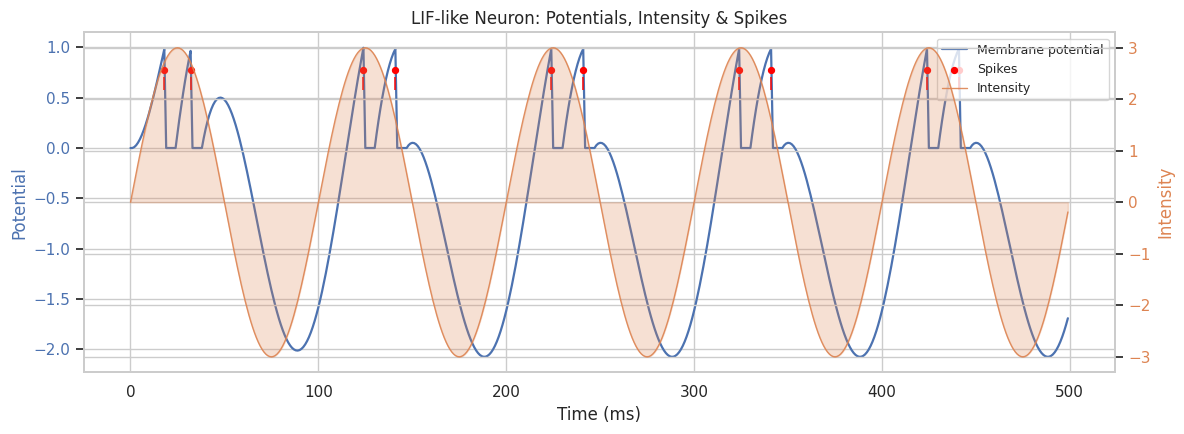

In [9]:
times = np.arange(0, SIMULATION_LENGTH/(STEP_SIZE*1000), STEP_SIZE/1000)
potential = REST_POTENTIAL
potentials = []
current_intensity = 0
intensities = []
spikes = []
spike_cooldown = 0

for t in times:
    current_intensity = intensity(t)
    intensities.append(current_intensity)

    potentials.append(potential)

    if spike_cooldown > 0:
        spike_cooldown -= 1
        spikes.append(0)
        continue

    potential = step_rk4(potential, t, STEP_SIZE,
                         derivative_potential, intensity=current_intensity)

    if spiked(potential):
        spikes.append(1)
        potential = spike_response(potential, REST_POTENTIAL)
        spike_cooldown = REFRACTORY_PERIOD

    else:
        spikes.append(0)

# Use the new pretty plotting helper: convert times (s) to ms inside helper
pretty_plot_results(times, potentials, intensities, spikes,
                    title="LIF-like Neuron: Potentials, Intensity & Spikes")